<a href="https://colab.research.google.com/github/KhushnurAnjum26/machine-Learning/blob/main/Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)


In [31]:
df = pd.read_csv("Iris.csv")


In [12]:
df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.shape


(150, 6)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
df.describe()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [14]:
df['Species'].value_counts()


,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


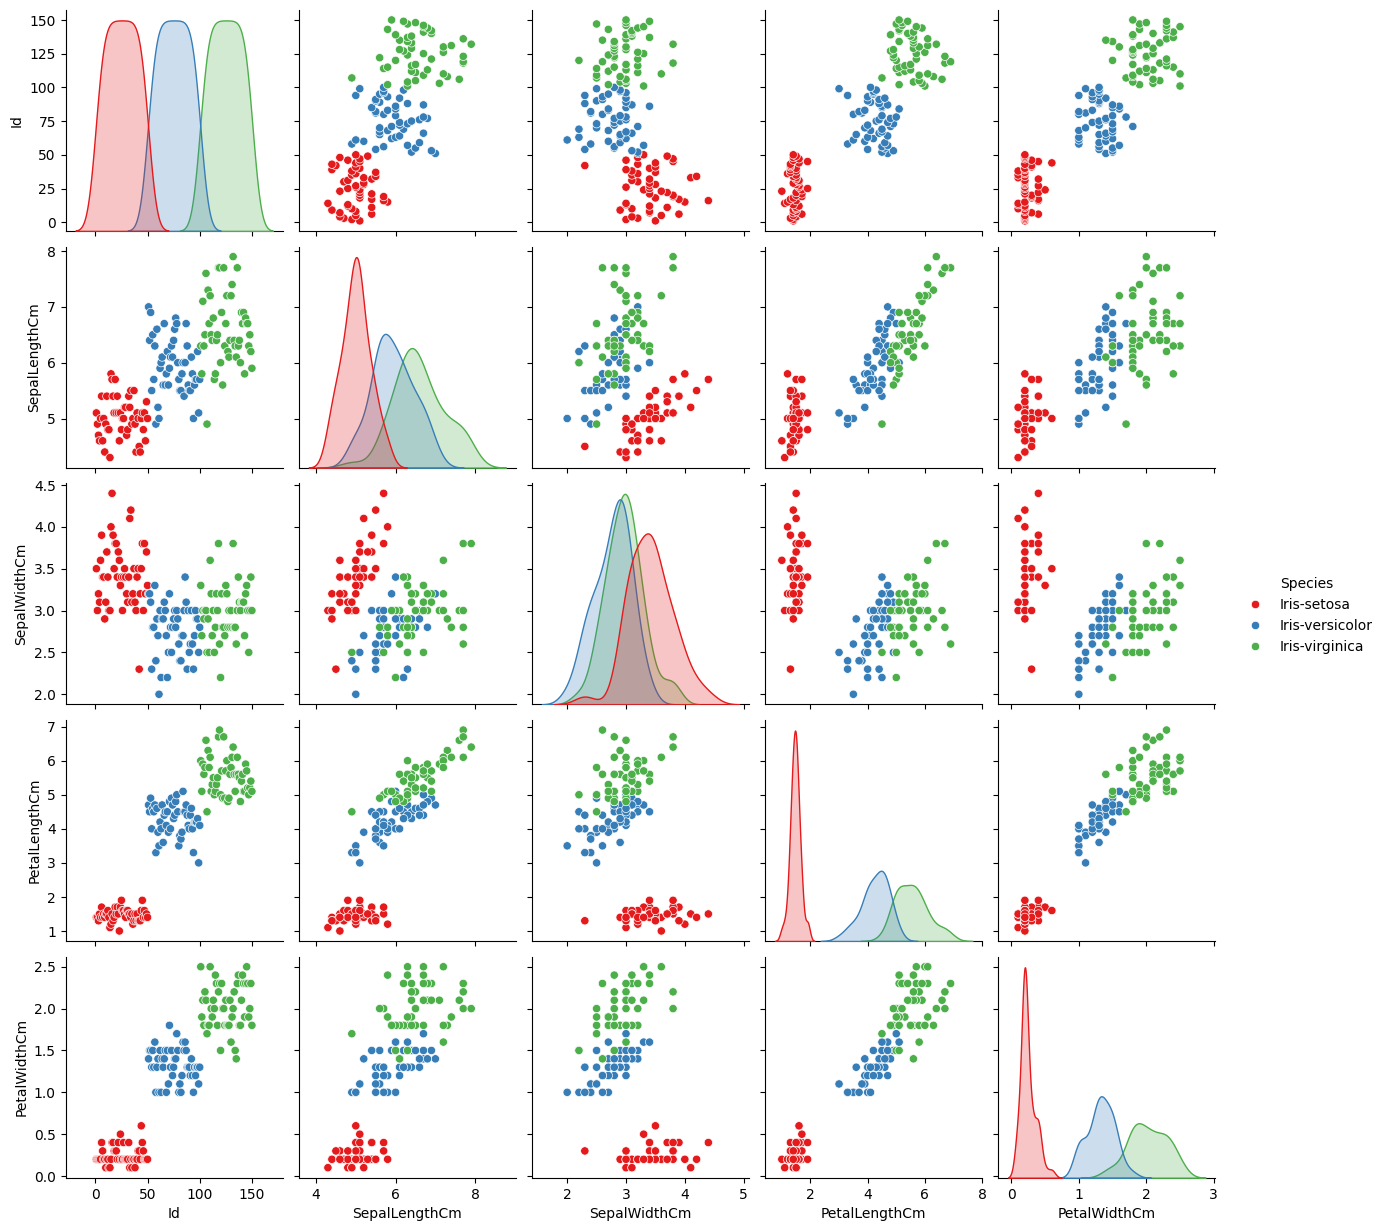

In [15]:
sns.pairplot(df, hue='Species', palette='Set1')
plt.show()


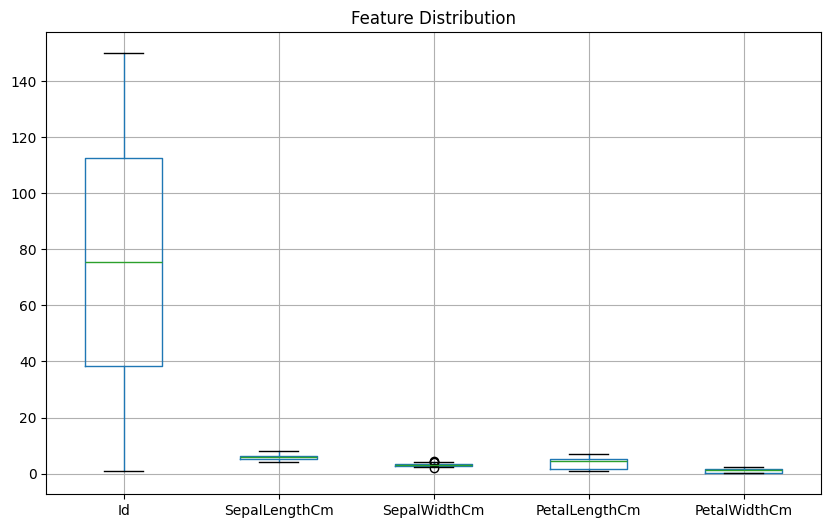

In [16]:
plt.figure(figsize=(10,6))
df.drop(columns='Species').boxplot()
plt.title("Feature Distribution")
plt.show()


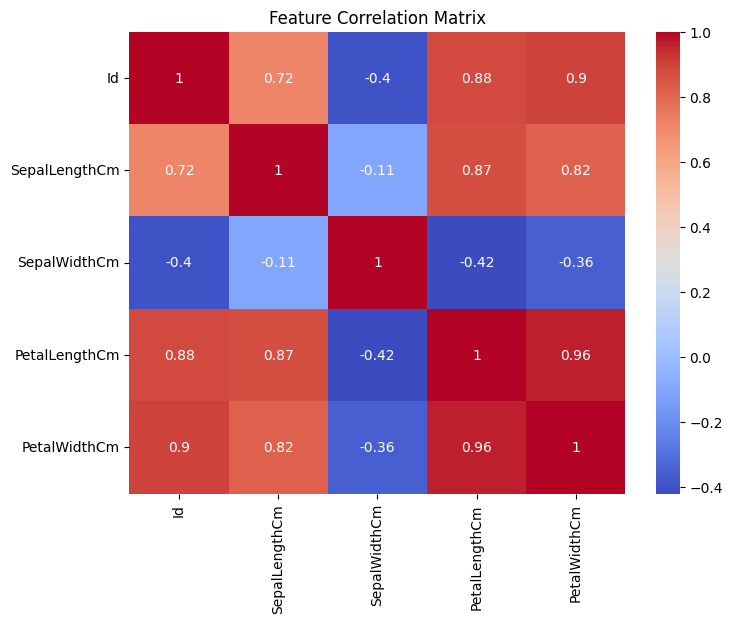

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.drop(columns='Species').corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Feature Correlation Matrix")
plt.show()


In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [32]:
nb_model = GaussianNB()


In [33]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


In [34]:
accuracies = []
precisions = []
recalls = []
f1_scores = []
conf_matrices = []

for train_idx, test_idx in skf.split(X_scaled, y):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    nb_model.fit(X_train, y_train)
    y_pred = nb_model.predict(X_test)

    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred, average='macro'))
    recalls.append(recall_score(y_test, y_pred, average='macro'))
    f1_scores.append(f1_score(y_test, y_pred, average='macro'))
    conf_matrices.append(confusion_matrix(y_test, y_pred))


In [35]:
print("Average Accuracy:", np.mean(accuracies))
print("Average Precision:", np.mean(precisions))
print("Average Recall:", np.mean(recalls))
print("Average F1 Score:", np.mean(f1_scores))


Average Accuracy: 0.9466666666666667
Average Precision: 0.9488215488215488
Average Recall: 0.9466666666666667
Average F1 Score: 0.9465329991645781


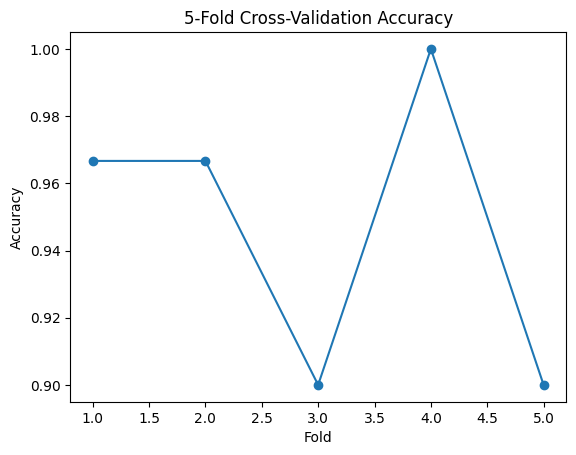

In [23]:
plt.figure()
plt.plot(range(1,6), accuracies, marker='o')
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("5-Fold Cross-Validation Accuracy")
plt.show()


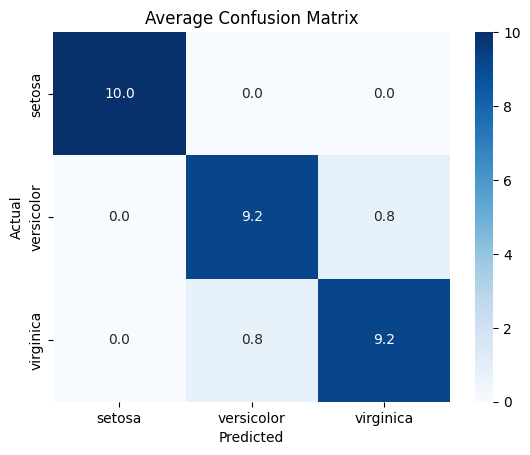

In [24]:
avg_cm = np.mean(conf_matrices, axis=0)

plt.figure()
sns.heatmap(
    avg_cm,
    annot=True,
    fmt='.1f',
    xticklabels=target_names,
    yticklabels=target_names,
    cmap='Blues'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Average Confusion Matrix")
plt.show()


In [25]:
X_2d = X_scaled[:, :2]
nb_model.fit(X_2d, y)
y_pred_2d = nb_model.predict(X_2d)


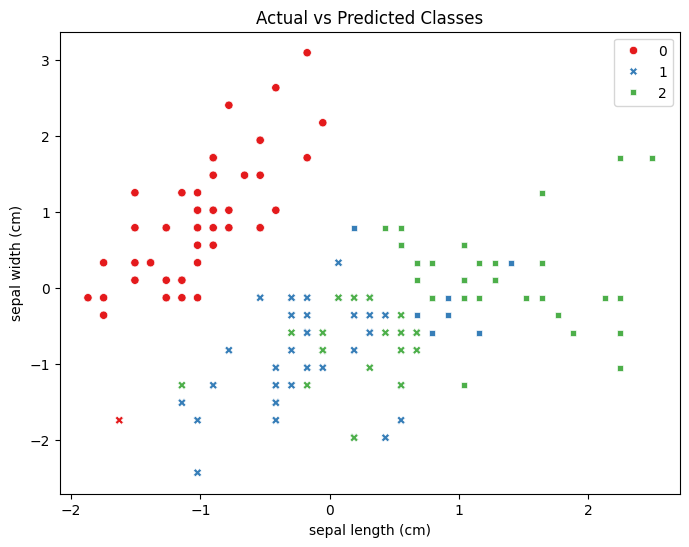

In [26]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_2d[:,0],
    y=X_2d[:,1],
    hue=y,
    style=y_pred_2d,
    palette='Set1'
)
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Actual vs Predicted Classes")
plt.show()


In [36]:
y_bin = label_binarize(y, classes=[0, 1, 2])
n_classes = y_bin.shape[1]


In [37]:
nb_model.fit(X_scaled, y)
y_score = nb_model.predict_proba(X_scaled)


In [38]:
fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


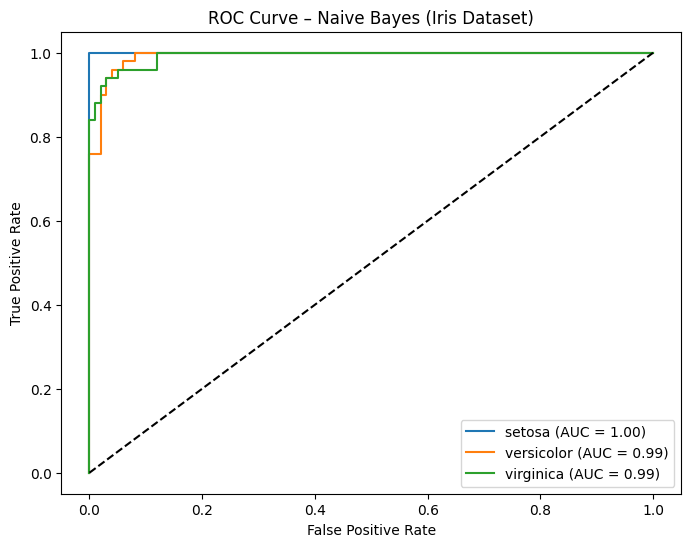

In [39]:
plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{target_names[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Naive Bayes (Iris Dataset)")
plt.legend(loc="lower right")
plt.show()
